# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [1]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [7]:
df = pd.read_csv('AviationData_clean.csv', low_memory=False)
print(df.shape)
print(df.head())

(59111, 33)
         Event.Id    Make  Destroyed  Fatal.Serious.Fraction  \
0  20001214X42095  CESSNA          0                     0.0   
1  20001214X42067  CESSNA          0                     0.0   
2  20001214X42063  CESSNA          0                     0.0   
3  20001214X42018   PIPER          0                     0.0   
4  20001214X41951  CESSNA          0                     0.0   

   Fatal.Serious.Injuries  Total.Occupants  Total.Uninjured  \
0                     0.0              4.0              3.0   
1                     0.0              2.0              2.0   
2                     0.0              1.0              1.0   
3                     0.0              2.0              0.0   
4                     0.0              2.0              2.0   

   Total.Minor.Injuries  Total.Serious.Injuries  Total.Fatal.Injuries  ...  \
0                   1.0                     0.0                   0.0  ...   
1                   0.0                     0.0                   0.

In [9]:
import os
print("Current folder:", os.getcwd())
print(list(df.columns))

Current folder: c:\Users\pc\.conda\dsc-course0-m8-lab
['Event.Id', 'Make', 'Destroyed', 'Fatal.Serious.Fraction', 'Fatal.Serious.Injuries', 'Total.Occupants', 'Total.Uninjured', 'Total.Minor.Injuries', 'Total.Serious.Injuries', 'Total.Fatal.Injuries', 'Investigation.Type', 'Amateur.Built', 'Model', 'Make.Model', 'Aircraft.Category', 'Aircraft.damage', 'Injury.Severity', 'Accident.Number', 'Event.Date', 'Location', 'Country', 'Registration.Number', 'Weather.Condition', 'Number.of.Engines', 'Report.Status', 'Engine.Type', 'Purpose.of.flight', 'Publication.Date', 'Broad.phase.of.flight', 'Airport.Name', 'Airport.Code', 'Latitude', 'Longitude']


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [10]:
df['Size'] = np.where(df['Total.Occupants'] >= 20, 'Large', 'Small')
print(df['Size'].value_counts())
print(df.groupby('Size')['Make'].nunique())

Size
Small    57719
Large     1392
Name: count, dtype: int64
Size
Large    20
Small    62
Name: Make, dtype: int64


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

SMALL (n>=30):
                     mean  count
Make                            
WACO             0.102657    138
HELIO            0.140620    105
CUBCRAFTERS INC  0.144068     59
LET              0.153061     98
MAULE            0.153281    569
BOEING           0.158934    571
GREAT LAKES      0.163793     58
SCHWEIZER        0.177570    107
BOEING STEARMAN  0.180000     50
WEATHERLY        0.188235     85
GRUMMAN          0.188665   1053
AVIAT            0.192130    216
STINSON          0.198139    421
SWEARINGEN       0.207978    143
LUSCOMBE         0.221934    386

LARGE (n>=10):
                       mean  count
Make                              
CANADAIR           0.026557     14
MCDONNELL DOUGLAS  0.053599    214
BOMBARDIER         0.066650     67
BOEING             0.099526    731
EMBRAER            0.118149     63
LOCKHEED           0.132848     26
AIRBUS             0.138369    123
DOUGLAS            0.160705     57
FAIRCHILD          0.193305     13
DE HAVILLAND       0.21

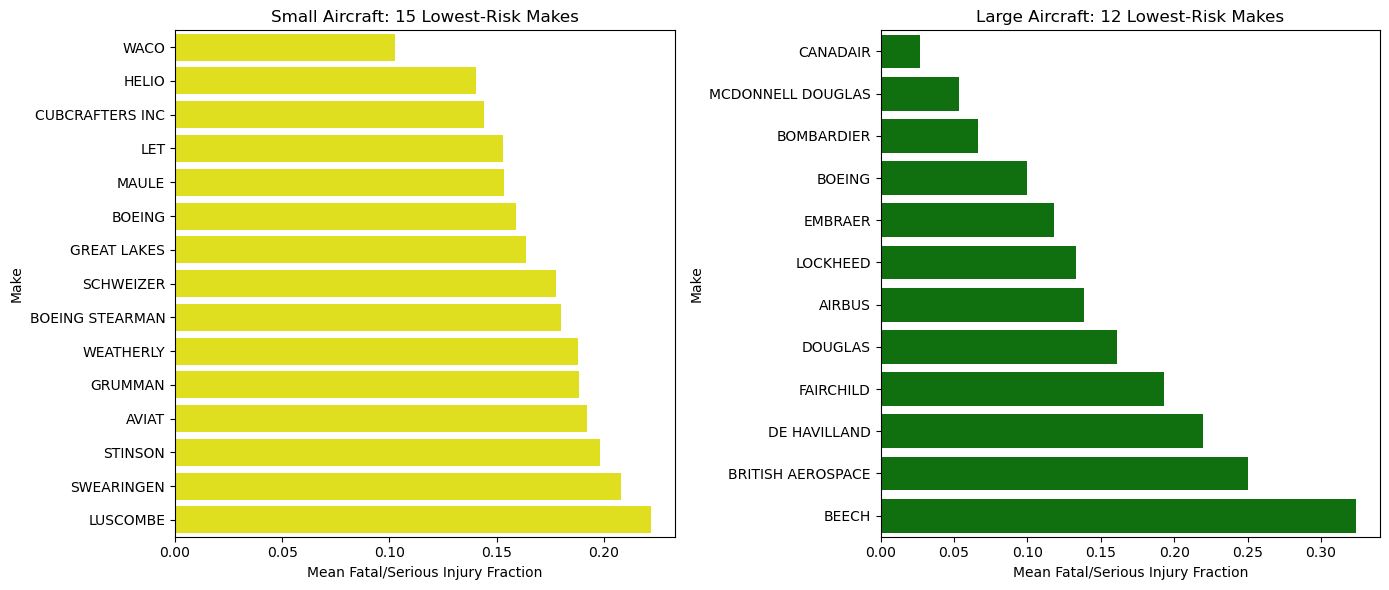

In [13]:
MIN_SMALL, MIN_LARGE = 30, 10
small = df[df['Size']=='Small']
large = df[df['Size']=='Large']

small_make = (small.groupby('Make')['Fatal.Serious.Fraction']
              .agg(['mean','count']).query('count>=@MIN_SMALL')
              .sort_values('mean').head(15))
large_make = (large.groupby('Make')['Fatal.Serious.Fraction']
              .agg(['mean','count']).query('count>=@MIN_LARGE')
              .sort_values('mean').head(15))

print('SMALL (n>=30):'); print(small_make)
print('\nLARGE (n>=10):'); print(large_make)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.barplot(x=small_make['mean'], y=small_make.index, ax=axes[0], color='yellow')
axes[0].set_title('Small Aircraft: 15 Lowest-Risk Makes')
axes[0].set_xlabel('Mean Fatal/Serious Injury Fraction')
sns.barplot(x=large_make['mean'], y=large_make.index, ax=axes[1], color='green')
axes[1].set_title(f'Large Aircraft: {len(large_make)} Lowest-Risk Makes')
axes[1].set_xlabel('Mean Fatal/Serious Injury Fraction')
plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

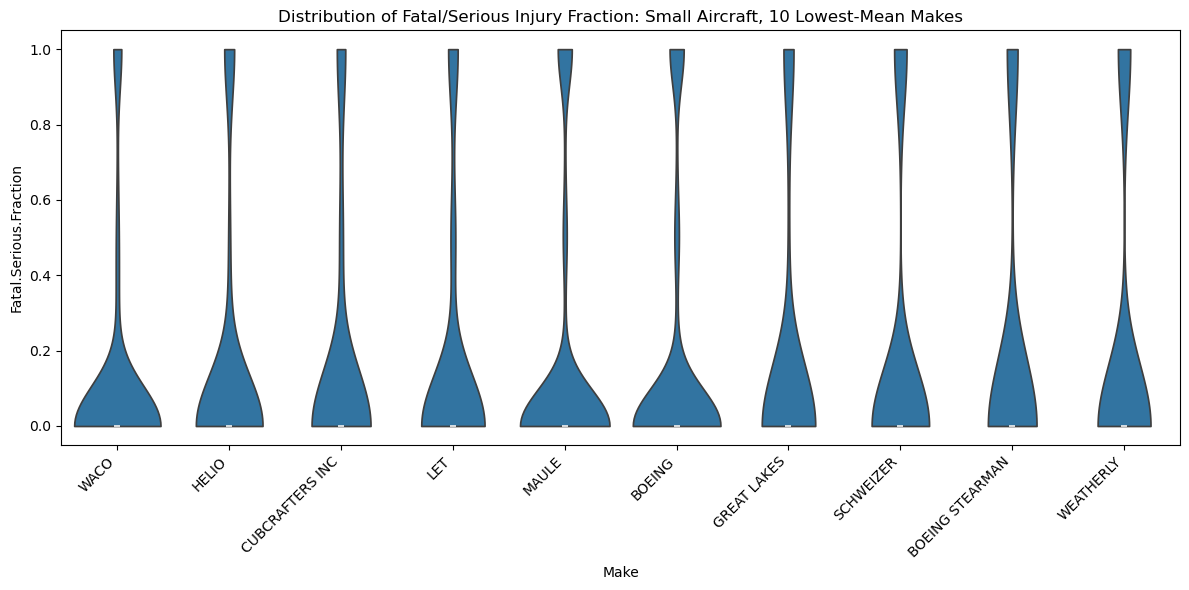

In [14]:
small_top10 = small_make.head(10).index.tolist()
sub = small[small['Make'].isin(small_top10)]
plt.figure(figsize=(12,6))
sns.violinplot(data=sub, x='Make', y='Fatal.Serious.Fraction', order=small_top10, cut=0)
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Fatal/Serious Injury Fraction: Small Aircraft, 10 Lowest-Mean Makes')
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

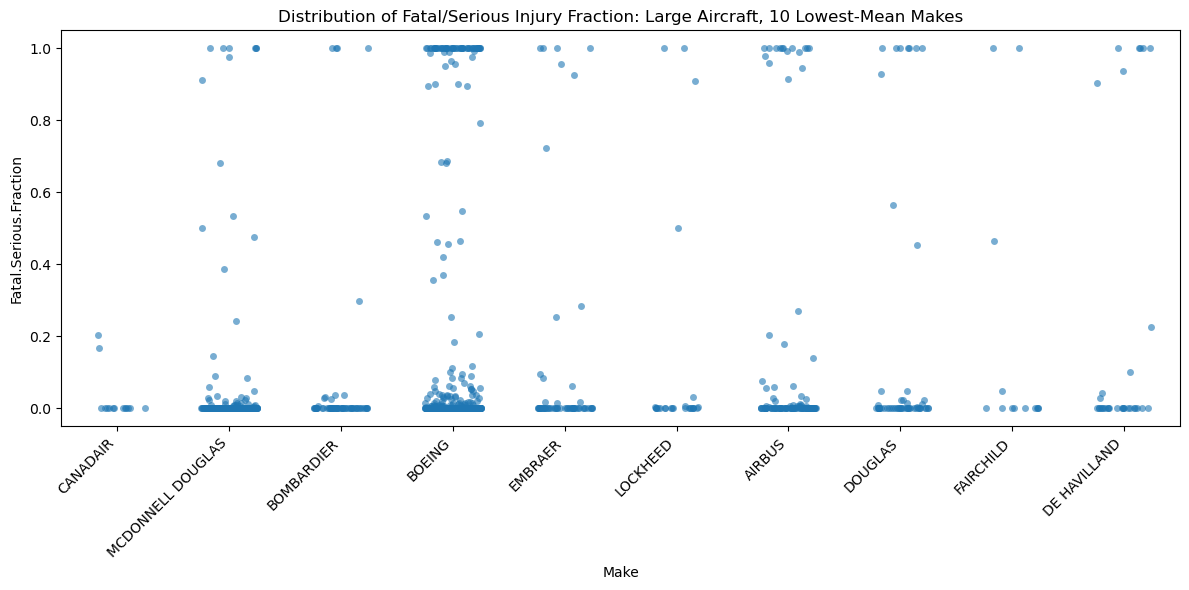

In [15]:
large_top10 = large_make.head(10).index.tolist()
sub2 = large[large['Make'].isin(large_top10)]
plt.figure(figsize=(12,6))
sns.stripplot(data=sub2, x='Make', y='Fatal.Serious.Fraction', order=large_top10, jitter=0.25, alpha=0.6)
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Fatal/Serious Injury Fraction: Large Aircraft, 10 Lowest-Mean Makes')
plt.tight_layout()
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

SMALL destroyed rate:
                                mean  count
Make                                       
CUBCRAFTERS INC             0.000000     59
SCHWEIZER                   0.046729    107
BELLANCA                    0.050459    218
FLIGHT DESIGN GMBH          0.060000     50
AVIAT                       0.069444    216
DIAMOND                     0.080247    162
WACO                        0.086957    138
MAULE                       0.093146    569
ERCOUPE                     0.094595     74
BOEING STEARMAN             0.100000     50
LET                         0.102041     98
LUSCOMBE                    0.103627    386
AIR TRACTOR INC             0.105505    218
AMERICAN CHAMPION AIRCRAFT  0.110000    100
TAYLORCRAFT                 0.123626    364

LARGE destroyed rate:
                       mean  count
Make                              
BOMBARDIER         0.059701     67
CANADAIR           0.071429     14
MCDONNELL DOUGLAS  0.088785    214
BOEING             0.109439    7

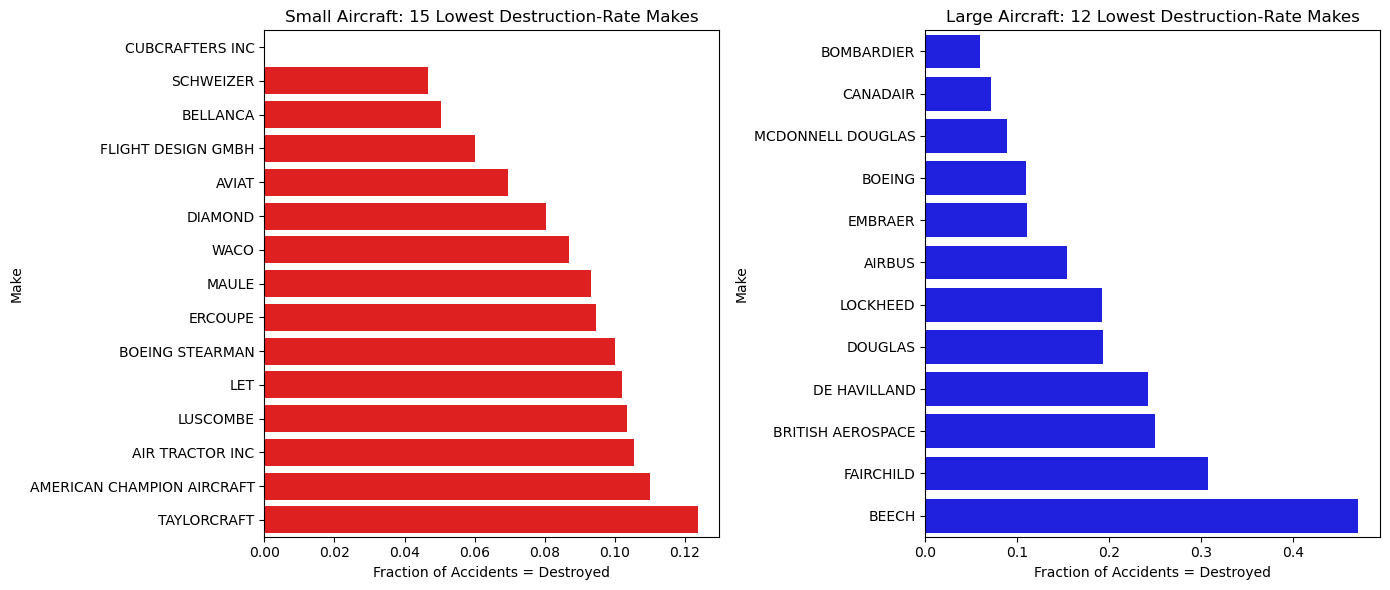

In [16]:
small_dest = (small.groupby('Make')['Destroyed'].agg(['mean','count'])
              .query('count>=@MIN_SMALL').sort_values('mean').head(15))
large_dest = (large.groupby('Make')['Destroyed'].agg(['mean','count'])
              .query('count>=@MIN_LARGE').sort_values('mean').head(15))

print('SMALL destroyed rate:'); print(small_dest)
print('\nLARGE destroyed rate:'); print(large_dest)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
sns.barplot(x=small_dest['mean'], y=small_dest.index, ax=axes[0], color='red')
axes[0].set_title('Small Aircraft: 15 Lowest Destruction-Rate Makes')
axes[0].set_xlabel('Fraction of Accidents = Destroyed')
sns.barplot(x=large_dest['mean'], y=large_dest.index, ax=axes[1], color='blue')
axes[1].set_title(f'Large Aircraft: {len(large_dest)} Lowest Destruction-Rate Makes')
axes[1].set_xlabel('Fraction of Accidents = Destroyed')
plt.tight_layout()
plt.show()

#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

**Recommendations by manufacturer**

- **Small aircraft:** Waco, Helio, CubCrafters, and Maule are the strongest picks each shows up in the top tier for both low injury fraction and low destruction rate, with big enough samples to trust. Schweizer and Bellanca stand out specifically on destruction resistance.
- **Large aircraft:** Bombardier, Canadair, McDonnell Douglas, and Boeing form the safest cluster on both metrics at once, backed by much larger sample sizes than most small-aircraft leaders.
- The injury-fraction distributions above are bimodal clustered near 0 or near 1, reflecting how few occupants are typically aboard small aircraft.
- Large-aircraft accidents cluster heavily at 0, consistent with most reportable large-aircraft accidents being runway excursions or minor incidents rather than fatal crashes.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

30 large-aircraft models qualify with n>=10 accidents
                                mean  count
Make.Model                                 
BOEING 777                  0.000000     18
BOEING 757-232              0.000000     10
BOEING 757-222              0.000000     10
MCDONNELL DOUGLAS MD-83     0.000938     13
MCDONNELL DOUGLAS MD-80     0.000978     11
MCDONNELL DOUGLAS MD-88     0.002760     20
MCDONNELL DOUGLAS DC-9-51   0.005693     11
BOMBARDIER CL-600-2B19      0.005881     22
MCDONNELL DOUGLAS DC-10-30  0.008389     12
BOEING 747                  0.009542     10
MCDONNELL DOUGLAS MD-11     0.020426     15
CANADAIR CL-600-2B19        0.020513     10
BOEING 727-232              0.026455     14
MCDONNELL DOUGLAS DC-10-10  0.034056     16
BOEING 727-200              0.052491     20


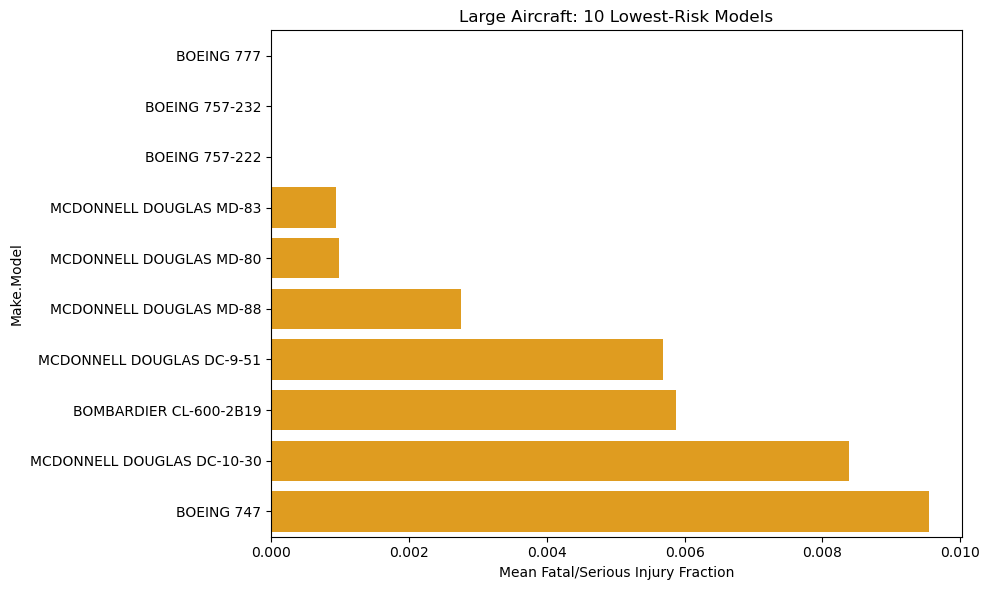

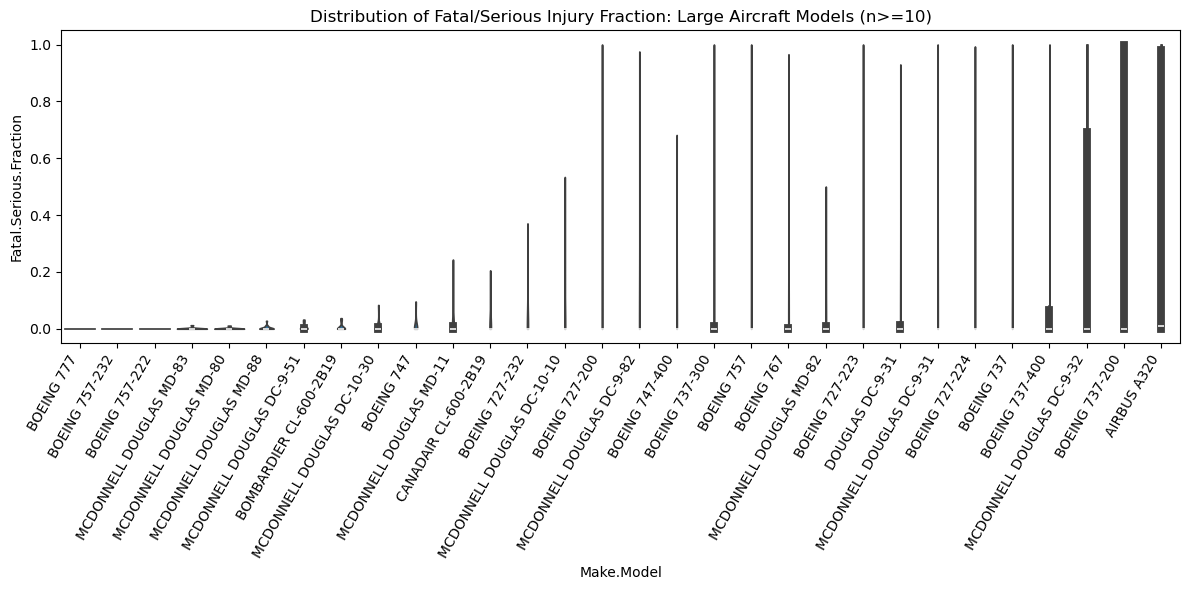

In [19]:
MIN_MODEL = 10
large_model = (large.groupby('Make.Model')['Fatal.Serious.Fraction']
               .agg(['mean','count']).query('count>=@MIN_MODEL').sort_values('mean'))
print(f'{len(large_model)} large-aircraft models qualify with n>=10 accidents')
print(large_model.head(15))

plt.figure(figsize=(10,6))
sns.barplot(x=large_model.head(10)['mean'], y=large_model.head(10).index, color='orange')
plt.title('Large Aircraft: 10 Lowest-Risk Models')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.tight_layout()
plt.show()

sub_l = large[large['Make.Model'].isin(large_model.index)]
plt.figure(figsize=(12,6))
sns.violinplot(data=sub_l, x='Make.Model', y='Fatal.Serious.Fraction', order=large_model.index, cut=0)
plt.xticks(rotation=60, ha='right')
plt.title('Distribution of Fatal/Serious Injury Fraction: Large Aircraft Models (n>=10)')
plt.tight_layout()
plt.show()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

745 small-aircraft models qualify with n>=10 accidents


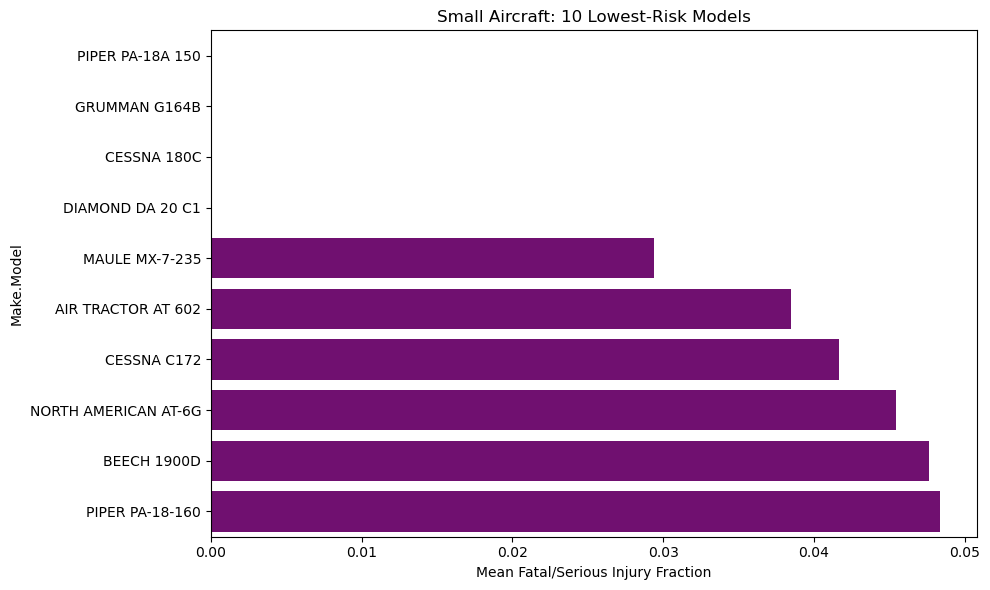

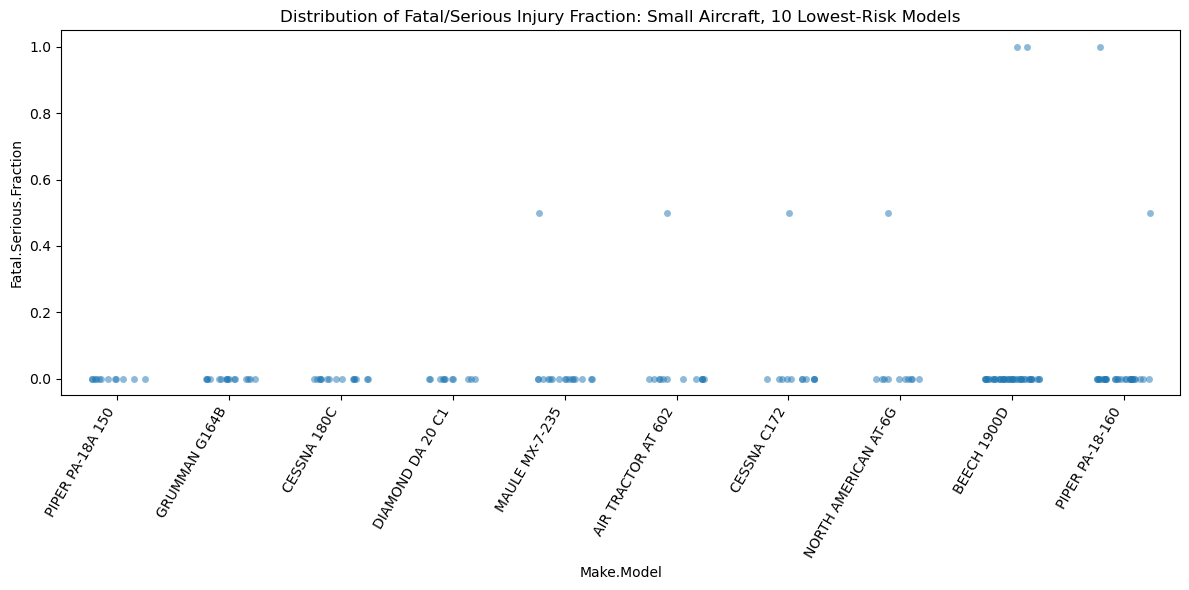

In [21]:
small_model = (small.groupby('Make.Model')['Fatal.Serious.Fraction']
               .agg(['mean','count']).query('count>=@MIN_MODEL').sort_values('mean'))
print(f'{len(small_model)} small-aircraft models qualify with n>=10 accidents')

plt.figure(figsize=(10,6))
sns.barplot(x=small_model.head(10)['mean'], y=small_model.head(10).index, color='purple')
plt.title('Small Aircraft: 10 Lowest-Risk Models')
plt.xlabel('Mean Fatal/Serious Injury Fraction')
plt.tight_layout()
plt.show()

sub_s = small[small['Make.Model'].isin(small_model.head(10).index)]
plt.figure(figsize=(12,6))
sns.stripplot(data=sub_s, x='Make.Model', y='Fatal.Serious.Fraction', order=small_model.head(10).index, jitter=0.25, alpha=0.5)
plt.xticks(rotation=60, ha='right')
plt.title('Distribution of Fatal/Serious Injury Fraction: Small Aircraft, 10 Lowest-Risk Models')
plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

**Specific model recommendations**

- **Small aircraft:** The Cessna 172 stands out as the best combination of a strong safety record and a large sample size. Piper PA-18 and Maule MX-7-235 are close behind.
- **Large aircraft:** The Boeing 777/757 and McDonnell Douglas MD-80/-83/-88 family show the strongest records, though the MD-80 family and Bombardier CL-600-2B19 have larger, more trustworthy samples.
- Zero injuries across 10+ accidents is a meaningfully strong signal, but not a guarantee.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

                  Fatal.Serious.Fraction        Destroyed       
                                    mean  count      mean  count
Weather.Condition                                               
VMC                             0.221084  51897  0.167100  51897
IMC                             0.662401   4754  0.583298   4754

t-test: t=-64.21, p=0.00e+00
Chi-square: chi2=4676.9, p=0.00e+00


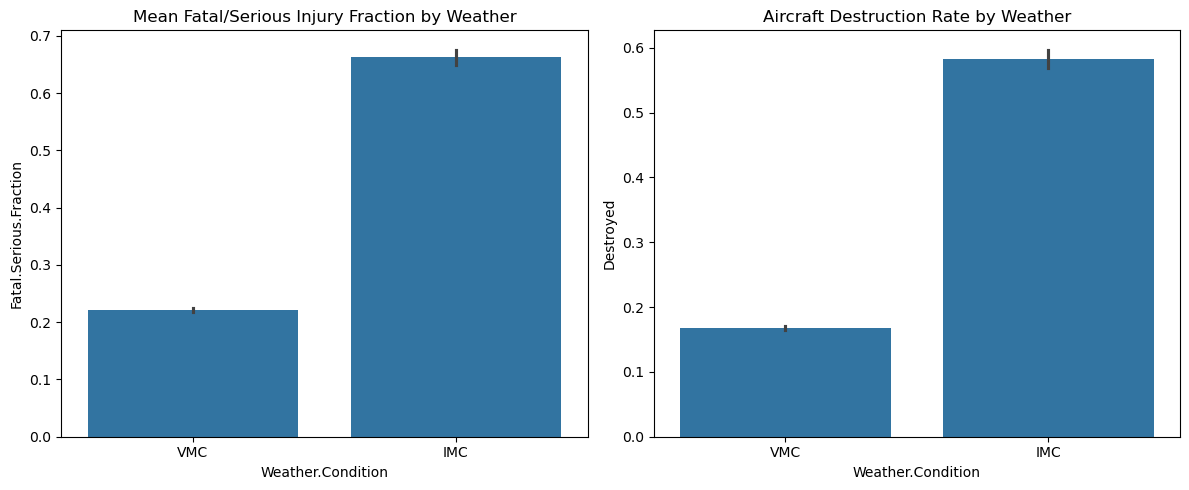

In [22]:
from scipy import stats

wx = df[df['Weather.Condition'].isin(['VMC','IMC'])]
print(df.groupby('Weather.Condition')[['Fatal.Serious.Fraction','Destroyed']]
      .agg(['mean','count']).loc[['VMC','IMC']])

t, p = stats.ttest_ind(wx.loc[wx['Weather.Condition']=='VMC','Fatal.Serious.Fraction'],
                        wx.loc[wx['Weather.Condition']=='IMC','Fatal.Serious.Fraction'],
                        equal_var=False)
print(f'\nt-test: t={t:.2f}, p={p:.2e}')

ct = pd.crosstab(wx['Weather.Condition'], wx['Destroyed'])
chi2, p2, dof, exp = stats.chi2_contingency(ct)
print(f'Chi-square: chi2={chi2:.1f}, p={p2:.2e}')

fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.barplot(data=wx, x='Weather.Condition', y='Fatal.Serious.Fraction', order=['VMC','IMC'], ax=axes[0], errorbar=('ci',95))
axes[0].set_title('Mean Fatal/Serious Injury Fraction by Weather')
sns.barplot(data=wx, x='Weather.Condition', y='Destroyed', order=['VMC','IMC'], ax=axes[1], errorbar=('ci',95))
axes[1].set_title('Aircraft Destruction Rate by Weather')
plt.tight_layout()
plt.show()

**Weather:** IMC accidents show 3x higher injury fraction and destruction rate than VMC statistically overwhelming given sample sizes in the tens of thousands.

                           mean  count
Broad.phase.of.flight                 
Taxi                   0.016280   1503
Landing                0.034731  11844
Standing               0.078928    517
Takeoff                0.226023   8805
Go-around              0.302213   1149
Descent                0.335107   1253
Approach               0.352086   4558
Cruise                 0.352658   7072
Climb                  0.415947   1423
Maneuvering            0.533817   4509


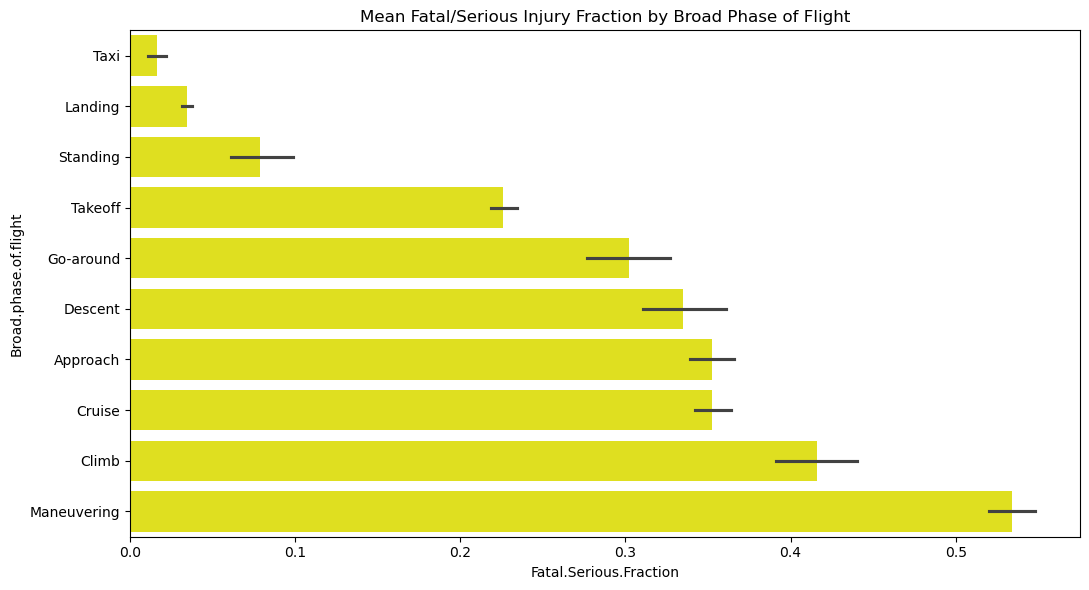

In [24]:
phase_stats = df.groupby('Broad.phase.of.flight')['Fatal.Serious.Fraction'].agg(['mean','count']).sort_values('mean')
print(phase_stats)

plt.figure(figsize=(11,6))
sns.barplot(data=df.dropna(subset=['Broad.phase.of.flight']), x='Fatal.Serious.Fraction', y='Broad.phase.of.flight',
            order=phase_stats.index, errorbar=('ci',95), color='yellow')
plt.title('Mean Fatal/Serious Injury Fraction by Broad Phase of Flight')
plt.tight_layout()
plt.show()

**Phase of flight:** Injury severity rises from ground phases to airborne phases Taxi/Landing safest, Maneuvering/Climb most dangerous, roughly 15-30x difference in risk. These two factors are the ones we identify as materially affecting outcomes independent of airframe choice.